Found 5 eligible records (showing up to 5).

BA2 96_2 Dy15 F12
  orig dims: {'width': 1128, 'height': 832}
  target dims: {'width': 512, 'height': 384}
  um/px orig: 1.6870567375886525
  um/px final: {'x': 3.716796875, 'y': 3.6552895981087468}
  stitched label: NoSplitNoStitched


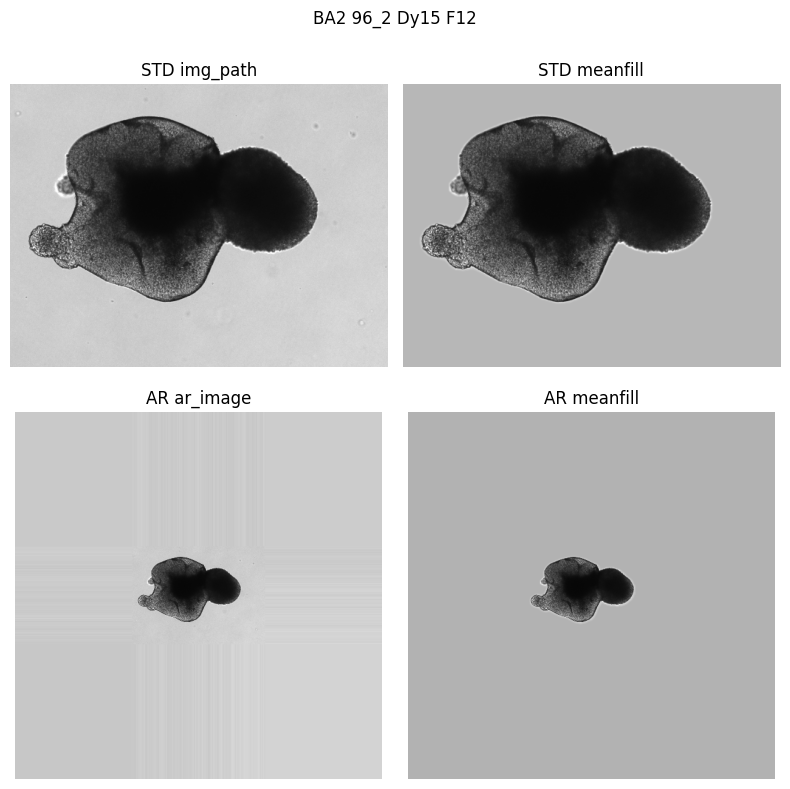


BA2 96_1 Dy30 A10
  orig dims: {'width': 1128, 'height': 832}
  target dims: {'width': 512, 'height': 384}
  um/px orig: 2.019503546099291
  um/px final: {'x': 4.44921875, 'y': 4.375591016548463}
  stitched label: NoSplitNoStitched


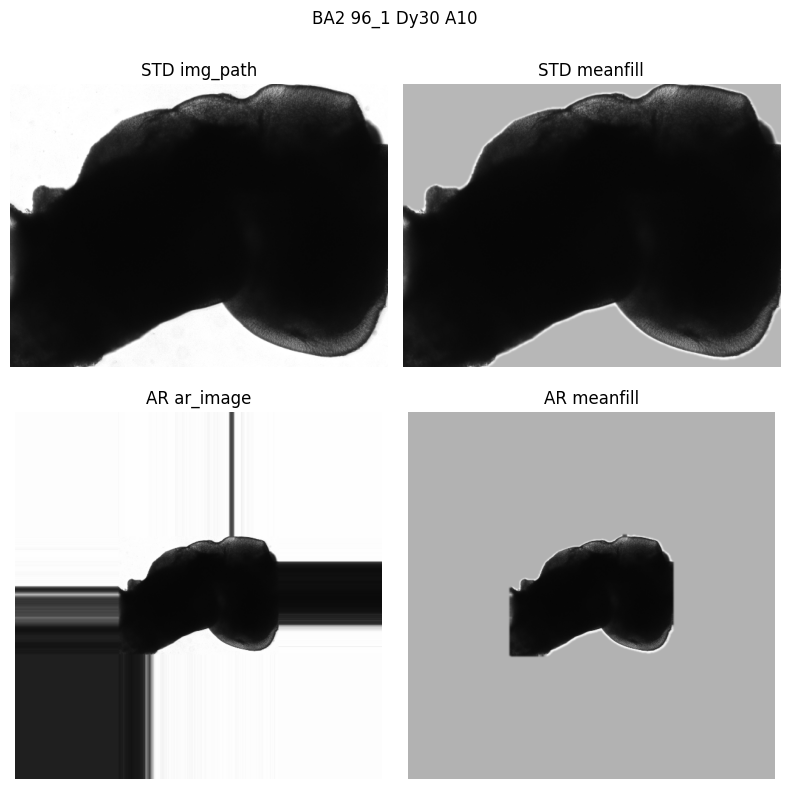


BA2 96_2 Dy15 B10
  orig dims: {'width': 1128, 'height': 832}
  target dims: {'width': 512, 'height': 384}
  um/px orig: 1.6870567375886525
  um/px final: {'x': 3.716796875, 'y': 3.6552895981087468}
  stitched label: NoSplitNoStitched


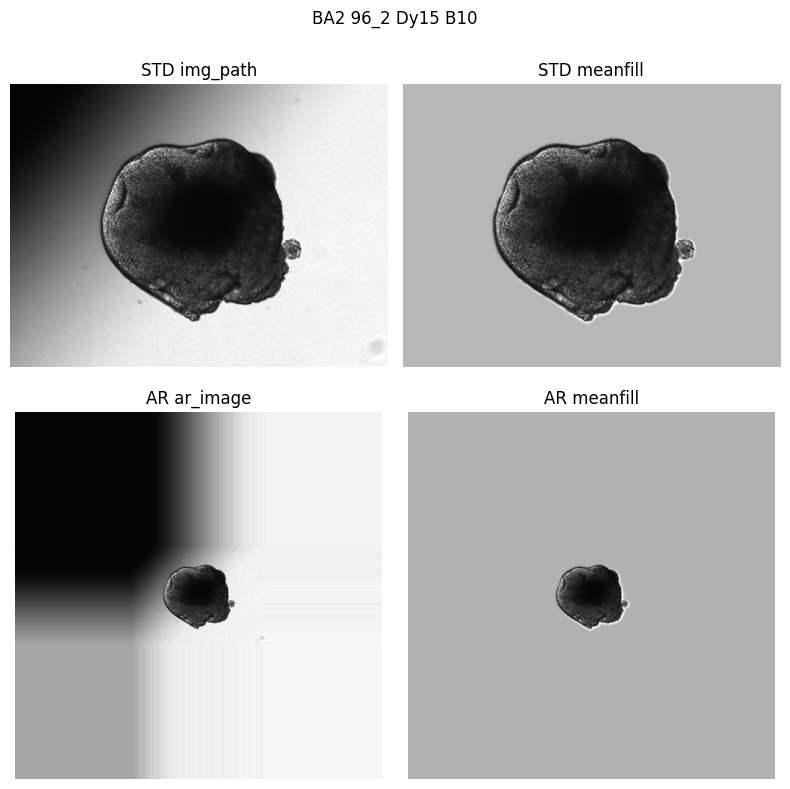


BA2 96_1 Dy20.5 H9
  orig dims: {'width': 1128, 'height': 832}
  target dims: {'width': 512, 'height': 384}
  um/px orig: 2.019503546099291
  um/px final: {'x': 4.44921875, 'y': 4.375591016548463}
  stitched label: NoSplitNoStitched


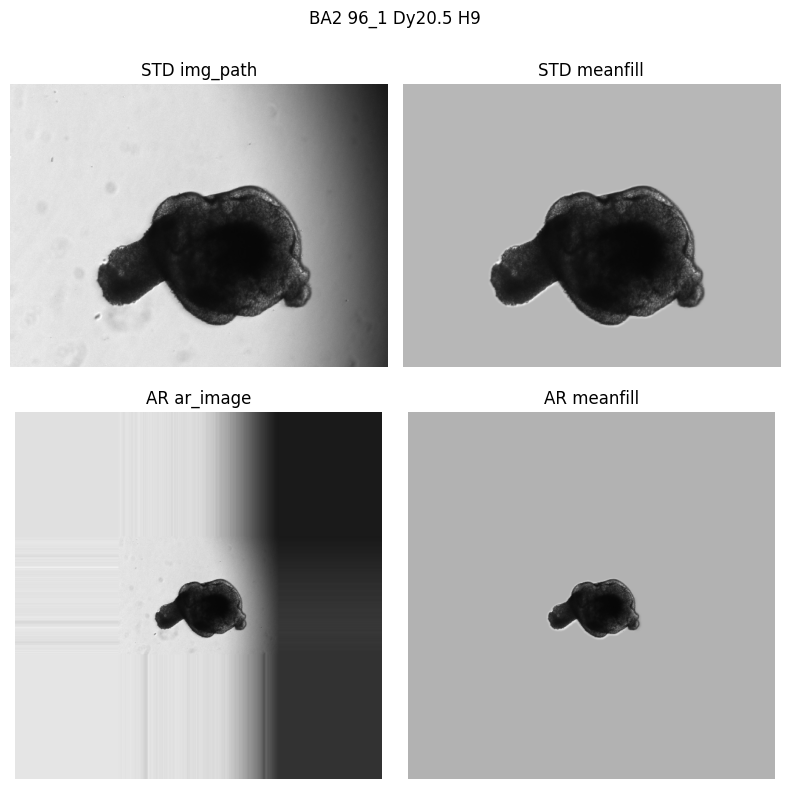


BA2 96_1 Dy17 G6
  orig dims: {'width': 1128, 'height': 832}
  target dims: {'width': 512, 'height': 384}
  um/px orig: 2.019503546099291
  um/px final: {'x': 4.44921875, 'y': 4.375591016548463}
  stitched label: NoSplitNoStitched


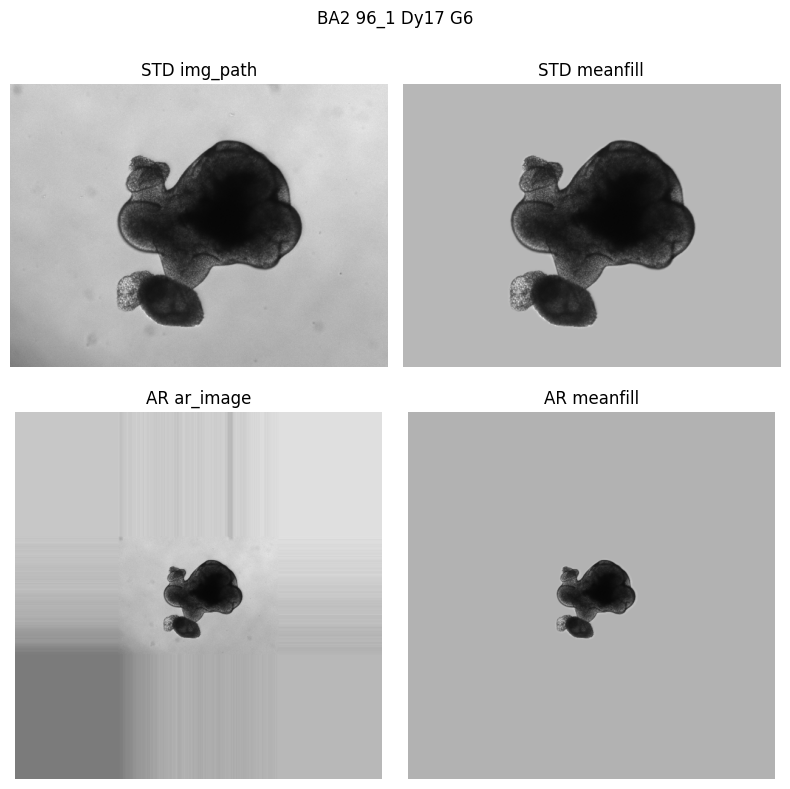


Top 5 by original pixel area:
- BA1 96_1 Dy24 A1
    orig_px: 2048 x 1536  (area=3,145,728)
    um/px orig: 2.2421875
    um/px final: {'x': 8.96875, 'y': 8.96875}
    verification: NoSplitNoStitched
- BA1 96_1 Dy24 A10
    orig_px: 2048 x 1536  (area=3,145,728)
    um/px orig: 2.2421875
    um/px final: {'x': 8.96875, 'y': 8.96875}
    verification: NoSplitNoStitched
- BA1 96_1 Dy24 A11
    orig_px: 2048 x 1536  (area=3,145,728)
    um/px orig: 2.2421875
    um/px final: {'x': 8.96875, 'y': 8.96875}
    verification: NoSplitNoStitched
- BA1 96_1 Dy24 A12
    orig_px: 2048 x 1536  (area=3,145,728)
    um/px orig: 2.2421875
    um/px final: {'x': 8.96875, 'y': 8.96875}
    verification: NoSplitNoStitched
- BA1 96_1 Dy24 A2
    orig_px: 2048 x 1536  (area=3,145,728)
    um/px orig: 2.2421875
    um/px final: {'x': 8.96875, 'y': 8.96875}
    verification: NoSplitNoStitched


In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
from skimage.io import imread

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
ALL_DATA = DATA_DIR / "identifiers/all_data.json"

# adjust if your AR images live somewhere else
AR_IMAGES_DIR_DEFAULT = DATA_DIR / "images/resized_575_square"

def resolve_path(p, fallback_dir=None):
    if not p:
        return None
    p = Path(p)
    if p.is_absolute():
        return p
    if fallback_dir is not None:
        return fallback_dir / p
    return p

def get_paths(rec):
    imgs = rec.get("images", {})

    std_img = resolve_path(imgs.get("img_path"))
    std_cm = resolve_path(imgs.get("clipped_meanfill", {}).get("std", {}).get("cm_image_abs"))

    # AR: sometimes it's just a filename, sometimes absolute; try default dir
    ar_image_field = imgs.get("aspect_ratio", {}).get("ar_image")
    ar_img = resolve_path(ar_image_field, fallback_dir=AR_IMAGES_DIR_DEFAULT)

    ar_cm = resolve_path(imgs.get("clipped_meanfill", {}).get("ar", {}).get("cm_image_abs"))

    return std_img, std_cm, ar_img, ar_cm

def record_has_all_files(rec):
    std_img, std_cm, ar_img, ar_cm = get_paths(rec)
    paths = [std_img, std_cm, ar_img, ar_cm]
    return all(p is not None and p.exists() for p in paths)

def show_quad(rec_id, rec):
    std_img, std_cm, ar_img, ar_cm = get_paths(rec)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(rec_id)

    panels = [
        ("STD img_path", std_img),
        ("STD meanfill", std_cm),
        ("AR ar_image", ar_img),
        ("AR meanfill", ar_cm),
    ]

    for ax, (title, path) in zip(axes.ravel(), panels):
        ax.imshow(imread(str(path)))
        ax.set_title(title)
        ax.axis("off")

    # useful per-record printout
    dims = rec.get("images", {}).get("dimensions_px", {})
    um = rec.get("images", {}).get("um_per_px", {})
    print(f"\n{rec_id}")
    print(f"  orig dims: {dims.get('orig')}")
    print(f"  target dims: {dims.get('target')}")
    print(f"  um/px orig: {um.get('orig')}")
    print(f"  um/px final: {um.get('final')}")
    print(f"  stitched label: {rec.get('metadata', {}).get('verification', {}).get('classification_verification')}")

    plt.tight_layout()
    plt.show()

# ----------------------------
# load all_data.json
# ----------------------------
with ALL_DATA.open("r") as f:
    all_data = json.load(f)

# ----------------------------
# 1) random 5 examples with std + ar + meanfill available
# ----------------------------
keys = list(all_data.keys())
random.shuffle(keys)

eligible = []
for k in keys:
    rec = all_data[k]
    if record_has_all_files(rec):
        eligible.append(k)
    if len(eligible) >= 5:
        break

print(f"Found {len(eligible)} eligible records (showing up to 5).")
for k in eligible:
    show_quad(k, all_data[k])

# ----------------------------
# 2) print top 5 largest original images (likely stitched)
# ----------------------------
def orig_area(rec):
    orig = rec.get("images", {}).get("dimensions_px", {}).get("orig", {})
    w = orig.get("width") or 0
    h = orig.get("height") or 0
    return w * h

top5 = sorted(all_data.items(), key=lambda kv: orig_area(kv[1]), reverse=True)[:5]

print("\nTop 5 by original pixel area:")
for rec_id, rec in top5:
    orig = rec.get("images", {}).get("dimensions_px", {}).get("orig", {})
    um = rec.get("images", {}).get("um_per_px", {})
    ver = rec.get("metadata", {}).get("verification", {}).get("classification_verification")
    print(f"- {rec_id}")
    print(f"    orig_px: {orig.get('width')} x {orig.get('height')}  (area={orig_area(rec):,})")
    print(f"    um/px orig: {um.get('orig')}")
    print(f"    um/px final: {um.get('final')}")
    print(f"    verification: {ver}")


In [2]:
import tifffile
from pathlib import Path

p = Path("/net/projects2/promega/data_reorg/data/images/raw_images/Ba2 96_2 Dy28 E12(stitched) Z2.tif")
with tifffile.TiffFile(str(p)) as tf:
    page = tf.pages[0]
    print("shape:", page.shape)
    print("XResolution:", page.tags.get("XResolution"))
    print("YResolution:", page.tags.get("YResolution"))
    print("ResolutionUnit:", page.tags.get("ResolutionUnit"))
    desc = page.tags.get("ImageDescription")
    print("Has ImageDescription:", desc is not None)
    if desc:
        print(str(desc.value)[:800])


shape: (1520, 1382, 3)
XResolution: TiffTag 282 XResolution @142 RATIONAL @215 = (406047, 1000000)
YResolution: TiffTag 283 YResolution @154 RATIONAL @223 = (406047, 1000000)
ResolutionUnit: TiffTag 296 ResolutionUnit @166 SHORT @174 = NONE
Has ImageDescription: True
ImageJ=1.54g
unit=\u00B5m


BA2 96_1 Dy30 A2 0.35626398210290827
BA2 96_1 Dy30 B1 0.3378076062639821
BA2 96_1 Dy28 A12 0.3193512304250559
BA2 96_1 Dy30 A10 0.31655480984340045
BA2 96_1 Dy28 A5 0.30648769574944074


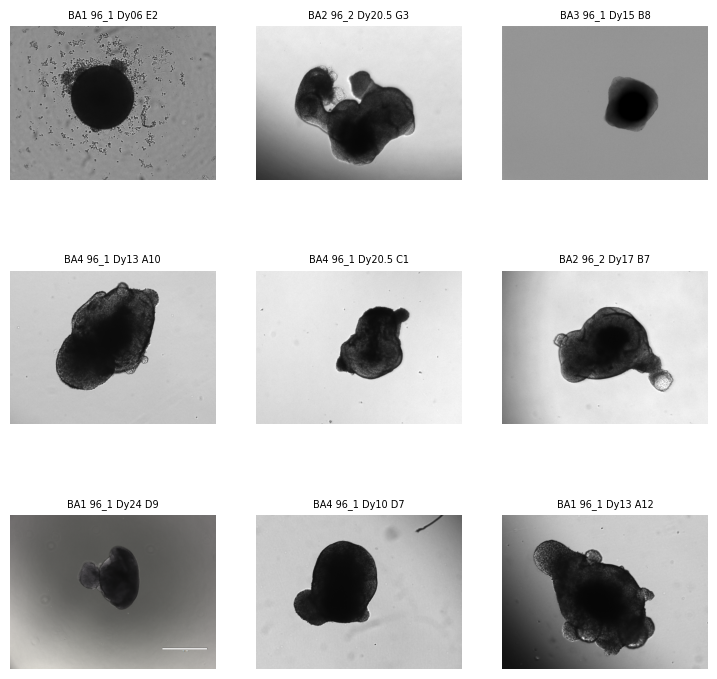

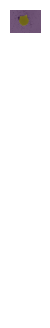

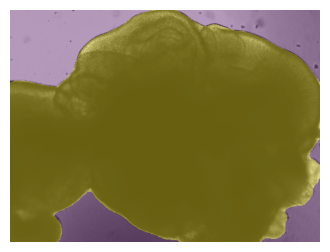

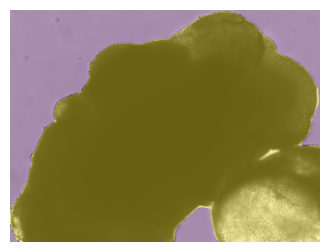

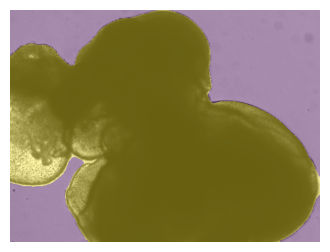

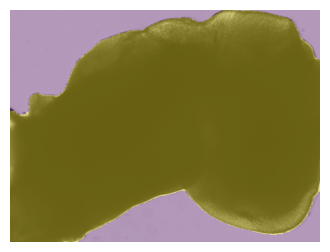

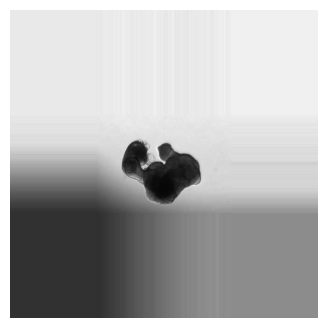

In [2]:
import json
from pathlib import Path
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
ALL_DATA = DATA_DIR / "identifiers/all_data.json"

with open(ALL_DATA) as f:
    data = json.load(f)

len(data)
def has_field(record, path):
    cur = record
    for p in path:
        if p not in cur:
            return False
        cur = cur[p]
    return True

required = [
    ["images", "img_path"],
    ["images", "mask_path"],
    ["images", "overlay_path"],
]

sum(
    all(has_field(r, p) for p in required)
    for r in data.values()
)

def load_img(p):
    return np.array(Image.open(p))

sample_keys = random.sample(list(data.keys()), 9)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, k in zip(axes.flat, sample_keys):
    img = load_img(data[k]["images"]["img_path"])
    ax.imshow(img)
    ax.set_title(k, fontsize=7)
    ax.axis("off")

def show_image_mask(record):
    img = load_img(record["images"]["img_path"])
    mask = load_img(record["images"]["mask_path"])

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.imshow(mask, alpha=0.4)
    plt.axis("off")

show_image_mask(data[sample_keys[0]])

edge_fracs = [
    r["images"].get("edge_fraction")
    for r in data.values()
    if "edge_fraction" in r["images"]
]

plt.hist(edge_fracs, bins=50)
plt.xlabel("edge_fraction")
plt.ylabel("count")

bad = sorted(
    data.items(),
    key=lambda x: x[1]["images"].get("edge_fraction", 0),
    reverse=True
)[:5]

for k, r in bad:
    print(k, r["images"]["edge_fraction"])
    show_image_mask(r)

def show_ar(record):
    ar = record["images"]["aspect_ratio"]
    ar_img = DATA_DIR / "images" / "resized_575_square" / ar["ar_image"]
    plt.imshow(load_img(ar_img))
    plt.axis("off")

show_ar(data[sample_keys[1]])


40

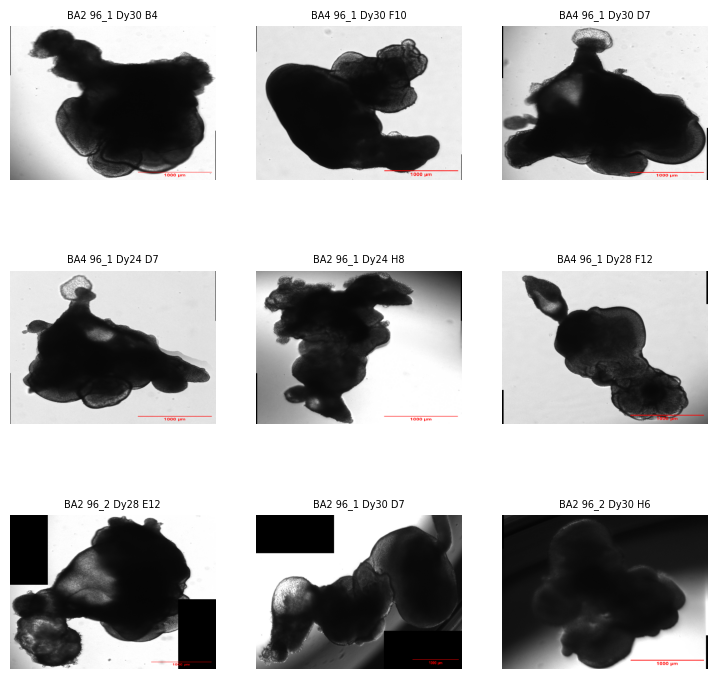

In [3]:

stitched = {
    k: r for k, r in data.items()
    if r["metadata"]["verification"]["classification_verification"] in {
        "NoSplitStitched",
        "SplitStitched",
    }
}
sample_stitched = random.sample(list(stitched.keys()), 9)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, k in zip(axes.flat, sample_stitched):
    img = load_img(data[k]["images"]["img_path"])
    ax.imshow(img)
    ax.set_title(k, fontsize=7)
    ax.axis("off")

len(stitched)


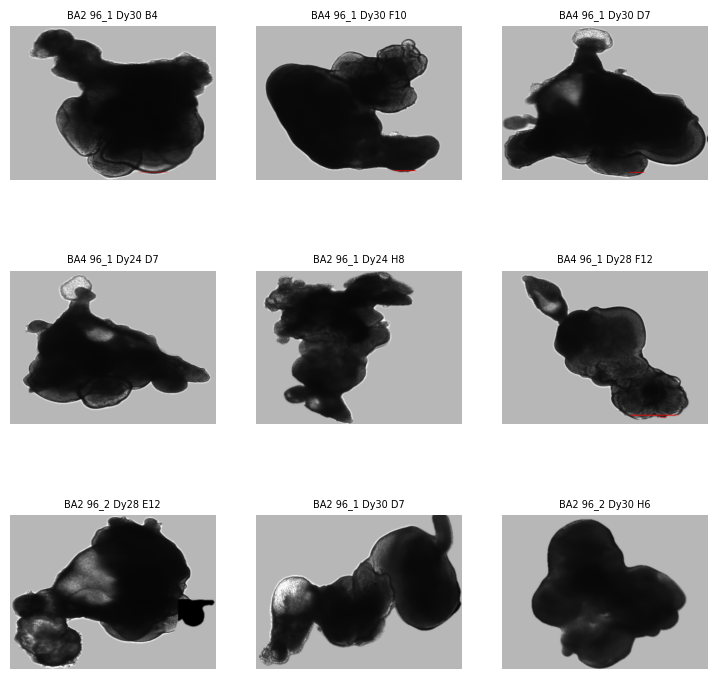

In [9]:
def load_ar_img(record):
    ar = record["images"]["clipped_meanfill"]
    return load_img(
        DATA_DIR / "images" / "resized_575_square" / ar["cm_image_abs"]
    )

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, k in zip(axes.flat, sample_stitched):
    ax.imshow(load_ar_img(data[k]))
    ax.set_title(k, fontsize=7)
    ax.axis("off")


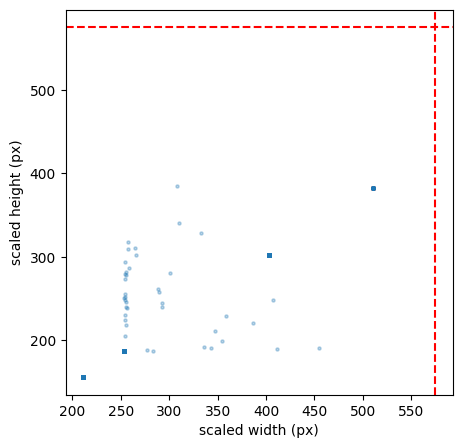

In [6]:
ar_sizes = [
    (
        r["images"]["aspect_ratio"]["ar_scaled_w"],
        r["images"]["aspect_ratio"]["ar_scaled_h"],
        r["metadata"]["verification"]["classification_verification"]
    )
    for r in data.values()
    if r["images"].get("aspect_ratio")
]

ws, hs, labels = zip(*ar_sizes)

plt.figure(figsize=(5,5))
plt.scatter(ws, hs, s=5, alpha=0.3)
plt.xlabel("scaled width (px)")
plt.ylabel("scaled height (px)")
plt.axvline(575, ls="--", c="r")
plt.axhline(575, ls="--", c="r")



AR mask area: 100%|██████████| 5168/5168 [01:21<00:00, 63.43it/s] 


records: 5168
kept: 5168
missing_ar: 0
missing_mask_file: 0
bad_day: 0


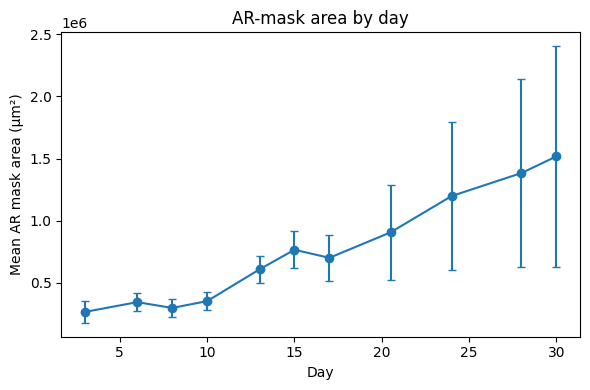

In [7]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

DATA_DIR = Path("/net/projects2/promega/project_data/amanda_test")
ALL_DATA_JSON = DATA_DIR / "identifiers" / "all_data.json"

# If your AR masks live elsewhere, adjust these two:
AR_MASK_DIR_DEFAULT_1 = DATA_DIR / "masks" / "resized_575_square"
AR_MASK_DIR_DEFAULT_2 = DATA_DIR / "images" / "resized_575_square"  # fallback (in case you saved masks w/ images)

with open(ALL_DATA_JSON, "r") as f:
    data = json.load(f)

def load_mask_as_bool(mask_path: Path) -> np.ndarray:
    # Treat any nonzero pixel as mask
    arr = np.array(Image.open(mask_path))
    if arr.ndim == 3:
        # if RGB/RGBA, collapse
        arr = arr[..., 0]
    return arr > 0

rows = []
missing_ar = 0
missing_mask_file = 0
bad_day = 0

for rid, r in tqdm(data.items(), total=len(data), desc="AR mask area"):
    day_num = r.get("day", {}).get("number", None)
    if day_num is None:
        bad_day += 1
        continue

    ar = r.get("images", {}).get("aspect_ratio", {})
    if not ar:
        missing_ar += 1
        continue

    ar_mask_name = ar.get("ar_mask", None)
    um_per_px = ar.get("ar_target_um_per_px", None)

    if not ar_mask_name or um_per_px is None:
        missing_ar += 1
        continue

    # Try to locate the AR mask file
    p1 = AR_MASK_DIR_DEFAULT_1 / ar_mask_name
    p2 = AR_MASK_DIR_DEFAULT_2 / ar_mask_name
    mask_path = p1 if p1.exists() else (p2 if p2.exists() else None)

    if mask_path is None:
        missing_mask_file += 1
        continue

    m = load_mask_as_bool(mask_path)
    mask_px = int(m.sum())
    area_um2 = mask_px * (float(um_per_px) ** 2)

    rows.append({
        "record_id": rid,
        "day": float(day_num),
        "mask_px": mask_px,
        "um_per_px": float(um_per_px),
        "area_um2": area_um2,
        "class_verif": r.get("metadata", {}).get("verification", {}).get("classification_verification", None),
    })

df = pd.DataFrame(rows)

print("records:", len(data))
print("kept:", len(df))
print("missing_ar:", missing_ar)
print("missing_mask_file:", missing_mask_file)
print("bad_day:", bad_day)

# mean area per day (sorted)
by_day = (
    df.groupby("day", as_index=False)
      .agg(n=("area_um2", "size"),
           mean_area_um2=("area_um2", "mean"),
           std_area_um2=("area_um2", "std"))
      .sort_values("day")
)

by_day

plt.figure(figsize=(6,4))
plt.errorbar(by_day["day"], by_day["mean_area_um2"], yerr=by_day["std_area_um2"], fmt="-o", capsize=3)
plt.xlabel("Day")
plt.ylabel("Mean AR mask area (µm²)")
plt.title("AR-mask area by day")
plt.tight_layout()
plt.show()


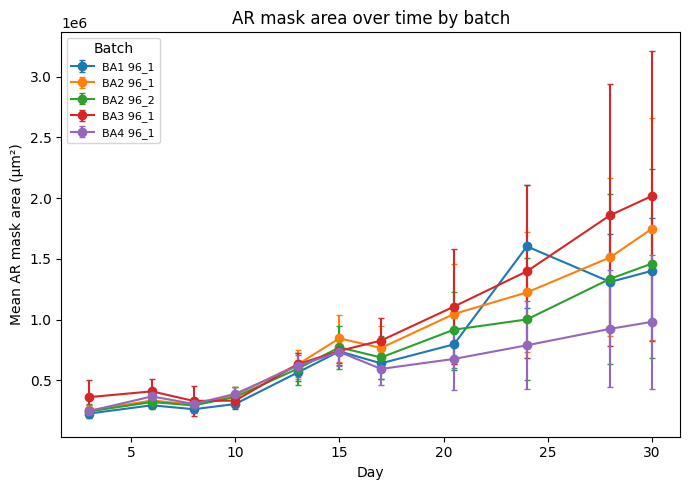

In [10]:
df["batch"] = df["record_id"].map(
    lambda k: data[k]["plate"]["batch"]
)
by_day_batch = (
    df.groupby(["batch", "day"], as_index=False)
      .agg(
          n=("area_um2", "size"),
          mean_area_um2=("area_um2", "mean"),
          std_area_um2=("area_um2", "std"),
      )
      .sort_values(["batch", "day"])
)

by_day_batch.head()
plt.figure(figsize=(7, 5))

for batch, sub in by_day_batch.groupby("batch"):
    plt.errorbar(
        sub["day"],
        sub["mean_area_um2"],
        yerr=sub["std_area_um2"],
        marker="o",
        capsize=2,
        label=batch
    )

plt.xlabel("Day")
plt.ylabel("Mean AR mask area (µm²)")
plt.title("AR mask area over time by batch")
plt.legend(title="Batch", fontsize=8)
plt.tight_layout()
plt.show()


In [14]:
print(data.columns)

AttributeError: 'dict' object has no attribute 'columns'

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from pathlib import Path

def show_random_meanfill_by_batch(
    df,
    path_col="cm_image_abs",
    n=10,
    seed=0,
    max_batches=None,  # set to e.g. 3 if you want to limit
):
    rng = np.random.default_rng(seed)

    batches = sorted(df["batch"].dropna().unique())
    if max_batches is not None:
        batches = batches[:max_batches]

    for batch in batches:
        sub = df[(df["batch"] == batch) & df[path_col].notna()].copy()

        # keep only paths that exist
        sub = sub[sub[path_col].map(lambda p: Path(p).exists())]

        if sub.empty:
            print(f"[{batch}] no valid meanfill images found.")
            continue

        k = min(n, len(sub))
        picks = sub.sample(n=k, random_state=seed)

        fig, axes = plt.subplots(2, 5, figsize=(14, 6))
        axes = axes.ravel()

        fig.suptitle(f"{batch}: meanfill_clip (random {k})", fontsize=14)

        for ax, (_, row) in zip(axes, picks.iterrows()):
            p = row[path_col]
            img = imread(p)
            ax.imshow(img)
            ax.set_title(row.get("record_id", ""), fontsize=7)
            ax.axis("off")

        # turn off unused axes if k < 10
        for ax in axes[k:]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

show_random_meanfill_by_batch(df, path_col="cm_image_abs", n=10, seed=42)


KeyError: 'cm_image_abs'